# PHASE 1 — SETUP AND DATA LOADING

In [12]:

# Pandas: works with tables (DataFrames) — our most used tool
import pandas as pd

# NumPy: handles numbers and math operations
import numpy as np

# Matplotlib and Seaborn: create charts and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# SQLite3: lets us run SQL queries inside Python
import sqlite3

# OS: helps with file paths
import os

# Suppress minor warnings so output stays clean
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
colors = sns.color_palette("muted")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [13]:
# Define the path to the data folder
# '..' means go one level up from notebooks/ into the project root
DATA_PATH = '../data/'

# Load all 9 CSV files into separate DataFrames
# A DataFrame is like an Excel sheet — rows and columns
customers    = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
orders       = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items  = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers      = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
geolocation  = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print("✅ All datasets loaded successfully")
print(f"\nDataset sizes:")
print(f"  Customers    : {customers.shape[0]:,} rows, {customers.shape[1]} columns")
print(f"  Orders       : {orders.shape[0]:,} rows, {orders.shape[1]} columns")
print(f"  Order Items  : {order_items.shape[0]:,} rows, {order_items.shape[1]} columns")
print(f"  Payments     : {payments.shape[0]:,} rows, {payments.shape[1]} columns")
print(f"  Reviews      : {reviews.shape[0]:,} rows, {reviews.shape[1]} columns")
print(f"  Products     : {products.shape[0]:,} rows, {products.shape[1]} columns")
print(f"  Sellers      : {sellers.shape[0]:,} rows, {sellers.shape[1]} columns")

✅ All datasets loaded successfully

Dataset sizes:
  Customers    : 99,441 rows, 5 columns
  Orders       : 99,441 rows, 8 columns
  Order Items  : 112,650 rows, 7 columns
  Payments     : 103,886 rows, 5 columns
  Reviews      : 99,224 rows, 7 columns
  Products     : 32,951 rows, 9 columns
  Sellers      : 3,095 rows, 4 columns


In [14]:
# .head(3) shows the first 3 rows — lets us to see what the data looks like
# This is always our first action when seeing new data as an analyst

print("=" * 60)
print("ORDERS TABLE — first 3 rows")
print("=" * 60)
display(orders.head(3))

print("\n" + "=" * 60)
print("ORDER ITEMS TABLE — first 3 rows")
print("=" * 60)
display(order_items.head(3))

print("\n" + "=" * 60)
print("PAYMENTS TABLE — first 3 rows")
print("=" * 60)
display(payments.head(3))

ORDERS TABLE — first 3 rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



ORDER ITEMS TABLE — first 3 rows


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



PAYMENTS TABLE — first 3 rows


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


In [15]:
# .info() shows column names, data types, and how many non-null values exist
# This tells us immediately where the problems are

print("ORDERS TABLE — structure and missing values")
print("-" * 50)
orders.info()

print("\nMissing values in ORDERS:")
print(orders.isnull().sum())

ORDERS TABLE — structure and missing values
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

Missing values in ORDERS:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approve

In [16]:
# ============================================================
# PHASE 2 — DATA CLEANING
# ============================================================

# All date columns are stored as plain text (object type)
# We need to convert them to datetime so Python understands
# they are dates and can calculate differences between them

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])
    # errors='coerce' converts anything that can't be parsed into NaT (null date)

print("✅ Date columns converted")
print("\nData types after conversion:")
print(orders[date_columns].dtypes)

✅ Date columns converted

Data types after conversion:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [17]:
# Check what order statuses exist
print("Order status breakdown:")
print(orders['order_status'].value_counts())
print(f"\nTotal orders before filtering: {len(orders):,}")

# We only want DELIVERED orders for sales analysis
# Cancelled, invoiced, processing etc. don't tell us about completed sales
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Also remove rows where delivery date is missing
# We need delivery date to calculate delivery time
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

print(f"\nTotal orders after filtering (delivered only): {len(orders_clean):,}")
print(f"Removed {len(orders) - len(orders_clean):,} non-delivered or incomplete records")

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders before filtering: 99,441

Total orders after filtering (delivered only): 96,470
Removed 2,971 non-delivered or incomplete records


In [18]:
# These new columns are derived from existing data
# Creating them now makes all future analysis much easier

# 1. How many days did delivery take?
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

# 2. Was delivery early or late vs the estimate?
# Negative = delivered early (good), Positive = delivered late (bad)
orders_clean['delivery_vs_estimate'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

# 3. Extract time components for trend analysis
orders_clean['order_year']    = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['order_month']   = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['order_yearmon'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
orders_clean['order_dow']     = orders_clean['order_purchase_timestamp'].dt.day_name()
orders_clean['order_hour']    = orders_clean['order_purchase_timestamp'].dt.hour

# 4. Delivery speed category — useful for comparison analysis
def delivery_bucket(days):
    if days <= 7:
        return '1_Fast (≤7 days)'
    elif days <= 14:
        return '2_Normal (8-14 days)'
    elif days <= 21:
        return '3_Slow (15-21 days)'
    else:
        return '4_Very Slow (>21 days)'

orders_clean['delivery_speed'] = orders_clean['delivery_days'].apply(delivery_bucket)

print("✅ Calculated columns created")
print(f"\nNew columns added: delivery_days, delivery_vs_estimate,")
print(f"order_year, order_month, order_yearmon, order_dow, order_hour, delivery_speed")
print(f"\nDelivery time summary:")
print(orders_clean['delivery_days'].describe().round(1))

✅ Calculated columns created

New columns added: delivery_days, delivery_vs_estimate,
order_year, order_month, order_yearmon, order_dow, order_hour, delivery_speed

Delivery time summary:
count    96470.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64


In [19]:
# Clean reviews — fill missing comment text
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No comment')
reviews['review_comment_title']   = reviews['review_comment_title'].fillna('No title')

# Add English category names to products
products_clean = products.merge(category_translation,
                                on='product_category_name',
                                how='left')
products_clean['product_category_name_english'] = \
    products_clean['product_category_name_english'].fillna('uncategorized')

print("✅ Reviews and products cleaned")
print(f"\nProduct categories available: {products_clean['product_category_name_english'].nunique()}")
print(f"Review scores distribution:")
print(reviews['review_score'].value_counts().sort_index())

✅ Reviews and products cleaned

Product categories available: 72
Review scores distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [21]:
# Fix: convert Period column to plain string so SQLite can accept it
# Period type (2017-01 as Period) → string (2017-01 as text)

orders_clean['order_yearmon'] = orders_clean['order_yearmon'].astype(str)

# Confirm the fix
print(f"order_yearmon dtype : {orders_clean['order_yearmon'].dtype}")
print(f"Sample values       : {orders_clean['order_yearmon'].unique()[:5]}")

order_yearmon dtype : str
Sample values       : <StringArray>
['2017-10', '2018-07', '2018-08', '2017-11', '2018-02']
Length: 5, dtype: str


In [22]:
# ============================================================
# PHASE 3 — SQL ANALYSIS
# ============================================================

# Create an in-memory SQLite database
# ':memory:' means it lives in RAM, not as a file on disk
conn = sqlite3.connect(':memory:')

# Load each cleaned DataFrame as a SQL table
orders_clean.to_sql('orders', conn, index=False, if_exists='replace')
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
products_clean.to_sql('products', conn, index=False, if_exists='replace')
sellers.to_sql('sellers', conn, index=False, if_exists='replace')

# Helper function — runs a SQL query and returns a DataFrame
def run_query(sql):
    return pd.read_sql(sql, conn)

print("✅ SQL database ready with all tables loaded")
print("\nTables available in SQL:")
tables = run_query("SELECT name FROM sqlite_master WHERE type='table'")
print(tables)

✅ SQL database ready with all tables loaded

Tables available in SQL:
          name
0       orders
1  order_items
2    customers
3     payments
4      reviews
5     products
6      sellers


In [23]:
# BUSINESS QUESTION 1
# Which product categories bring in the most money?
# This helps the business decide where to invest in marketing and inventory

q1 = run_query("""
    SELECT 
        p.product_category_name_english   AS category,
        ROUND(SUM(pay.payment_value), 2)  AS total_revenue,
        COUNT(DISTINCT o.order_id)        AS total_orders,
        ROUND(AVG(pay.payment_value), 2)  AS avg_order_value
    FROM orders o
    JOIN order_items  oi  ON o.order_id  = oi.order_id
    JOIN products     p   ON oi.product_id = p.product_id
    JOIN payments     pay ON o.order_id  = pay.order_id
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print("TOP 10 REVENUE-GENERATING CATEGORIES")
print("=" * 55)
print(q1.to_string(index=False))

TOP 10 REVENUE-GENERATING CATEGORIES
             category  total_revenue  total_orders  avg_order_value
       bed_bath_table     1692714.28          9272           145.30
        health_beauty     1620684.04          8646           166.07
computers_accessories     1549252.47          6529           196.18
      furniture_decor     1394466.93          6307           162.96
        watches_gifts     1387046.31          5493           228.77
       sports_leisure     1349252.93          7529           154.52
           housewares     1069787.97          5743           149.16
                 auto      833610.84          3809           194.63
         garden_tools      810614.93          3448           181.59
           cool_stuff      744649.32          3559           190.59


In [24]:
# BUSINESS QUESTION 2
# How has revenue grown month over month?
# Identifies growth trajectory, seasonal peaks, and anomalies

q2 = run_query("""
    SELECT 
        strftime('%Y-%m', o.order_purchase_timestamp) AS year_month,
        ROUND(SUM(pay.payment_value), 2)              AS monthly_revenue,
        COUNT(DISTINCT o.order_id)                    AS monthly_orders
    FROM orders o
    JOIN payments pay ON o.order_id = pay.order_id
    GROUP BY year_month
    ORDER BY year_month
""")

# Remove the first and last month as they're likely incomplete
q2 = q2.iloc[1:-1].reset_index(drop=True)

print("MONTHLY REVENUE TREND")
print("=" * 45)
print(q2.to_string(index=False))

MONTHLY REVENUE TREND
year_month  monthly_revenue  monthly_orders
   2016-12            19.62               1
   2017-01        127545.67             750
   2017-02        271298.65            1653
   2017-03        414369.39            2546
   2017-04        390952.18            2303
   2017-05        566872.73            3545
   2017-06        490225.60            3135
   2017-07        566403.93            3872
   2017-08        646000.61            4193
   2017-09        701169.99            4150
   2017-10        751140.27            4478
   2017-11       1153393.22            7288
   2017-12        843199.17            5513
   2018-01       1078606.86            7069
   2018-02        966510.88            6555
   2018-03       1120678.00            7003
   2018-04       1132933.95            6798
   2018-05       1128836.69            6749
   2018-06       1011561.35            6096
   2018-07       1027383.10            6156


In [25]:
# BUSINESS QUESTION 3
# Which customer states have the worst delivery times?
# Logistics insight — where should the business improve its supply chain?

q3 = run_query("""
    SELECT 
        c.customer_state                      AS state,
        ROUND(AVG(o.delivery_days), 1)        AS avg_delivery_days,
        ROUND(MIN(o.delivery_days), 1)        AS fastest_delivery,
        ROUND(MAX(o.delivery_days), 1)        AS slowest_delivery,
        COUNT(*)                              AS total_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY state
    HAVING total_orders > 100
    ORDER BY avg_delivery_days DESC
    LIMIT 10
""")

print("STATES WITH SLOWEST AVERAGE DELIVERY TIMES")
print("=" * 60)
print(q3.to_string(index=False))

STATES WITH SLOWEST AVERAGE DELIVERY TIMES
state  avg_delivery_days  fastest_delivery  slowest_delivery  total_orders
   AM               26.0               4.0             138.0           145
   AL               24.0               4.0              90.0           397
   PA               23.3               4.0             195.0           946
   MA               21.1               3.0             168.0           717
   SE               21.0               6.0             194.0           335
   CE               20.8               2.0             168.0          1279
   PB               20.0               5.0             102.0           517
   PI               19.0               2.0             194.0           476
   RO               18.9               7.0              50.0           243
   BA               18.9               0.0             167.0          3256


In [26]:
# BUSINESS QUESTION 4
# Do customers rate the experience higher when delivery is faster?
# This proves or disproves whether logistics investment improves satisfaction

q4 = run_query("""
    SELECT 
        o.delivery_speed,
        ROUND(AVG(r.review_score), 2) AS avg_review_score,
        COUNT(*)                      AS order_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct_of_orders
    FROM orders o
    JOIN reviews r ON o.order_id = r.order_id
    GROUP BY o.delivery_speed
    ORDER BY o.delivery_speed
""")

print("DELIVERY SPEED vs CUSTOMER SATISFACTION")
print("=" * 60)
print(q4.to_string(index=False))

DELIVERY SPEED vs CUSTOMER SATISFACTION
        delivery_speed  avg_review_score  order_count  pct_of_orders
      1_Fast (≤7 days)              4.41        33683           35.0
  2_Normal (8-14 days)              4.29        36395           37.8
   3_Slow (15-21 days)              4.10        15381           16.0
4_Very Slow (>21 days)              3.01        10894           11.3


In [27]:
# BUSINESS QUESTION 5
# When do customers place the most orders?
# Helps marketing team time campaigns and promotions correctly

q5_hours = run_query("""
    SELECT 
        order_hour,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_hour
    ORDER BY order_hour
""")

q5_days = run_query("""
    SELECT 
        order_dow,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_dow
    ORDER BY order_count DESC
""")

print("ORDERS BY HOUR OF DAY:")
print(q5_hours.to_string(index=False))
print("\nORDERS BY DAY OF WEEK:")
print(q5_days.to_string(index=False))

ORDERS BY HOUR OF DAY:
 order_hour  order_count
          0         2321
          1         1133
          2          496
          3          259
          4          203
          5          182
          6          477
          7         1199
          8         2907
          9         4647
         10         5978
         11         6385
         12         5802
         13         6309
         14         6383
         15         6249
         16         6475
         17         5961
         18         5585
         19         5801
         20         6007
         21         6039
         22         5658
         23         4014

ORDERS BY DAY OF WEEK:
order_dow  order_count
   Monday        15701
  Tuesday        15502
Wednesday        15074
 Thursday        14322
   Friday        13684
   Sunday        11632
 Saturday        10555


In [28]:
# BUSINESS QUESTION 6
# Which sellers generate the most revenue?
# Marketplace intelligence — who are the platform's most valuable sellers?

q6 = run_query("""
    SELECT 
        s.seller_state,
        COUNT(DISTINCT oi.seller_id)          AS seller_count,
        ROUND(SUM(pay.payment_value), 2)      AS total_revenue,
        ROUND(AVG(pay.payment_value), 2)      AS avg_order_value
    FROM order_items oi
    JOIN sellers  s   ON oi.seller_id  = s.seller_id
    JOIN payments pay ON oi.order_id   = pay.order_id
    GROUP BY s.seller_state
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print("TOP SELLER STATES BY REVENUE")
print("=" * 55)
print(q6.to_string(index=False))

TOP SELLER STATES BY REVENUE
seller_state  seller_count  total_revenue  avg_order_value
          SP          1849    13369880.61           159.44
          PR           349     1846047.66           204.80
          MG           244     1564757.80           168.98
          RJ           171     1098242.23           218.90
          SC           190      886745.47           208.30
          RS           129      560236.38           245.39
          BA            19      367899.46           527.08
          DF            30      137784.98           145.50
          PE             9      124894.83           268.59
          GO            40      112183.09           204.34


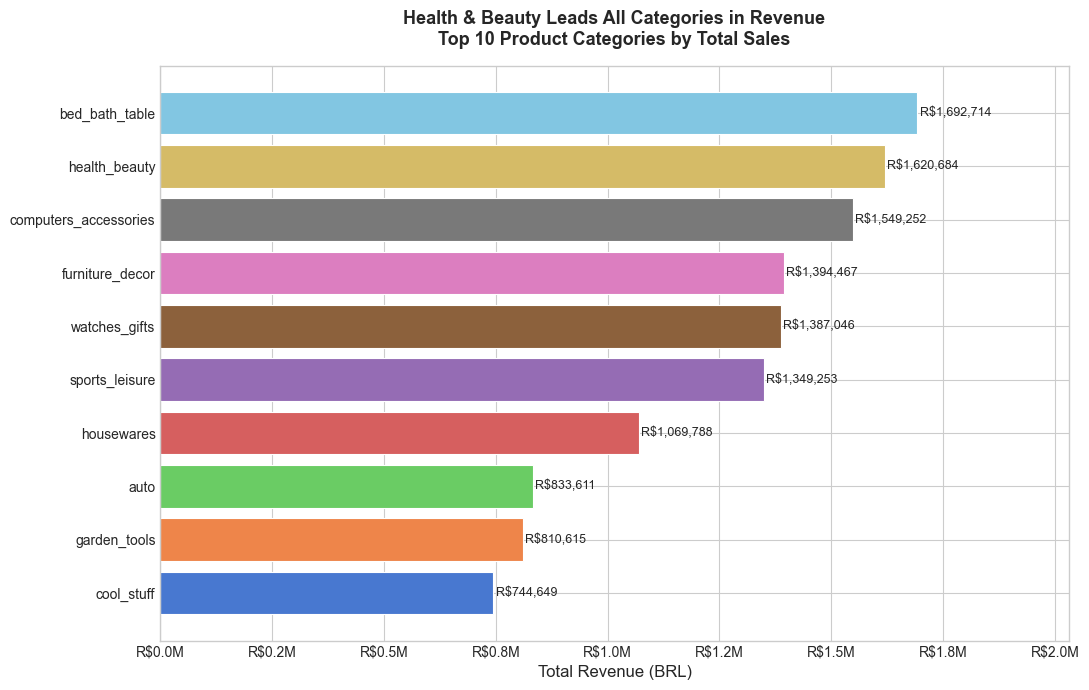

✅ Chart 1 saved


In [29]:
# ============================================================
# PHASE 4 — VISUALIZATIONS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Sort so highest revenue is at top
q1_sorted = q1.sort_values('total_revenue', ascending=True)

bars = ax.barh(q1_sorted['category'],
               q1_sorted['total_revenue'],
               color=sns.color_palette("muted", len(q1_sorted)),
               edgecolor='white', linewidth=0.8)

# Add value labels at end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5000, bar.get_y() + bar.get_height()/2,
            f'R${width:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Total Revenue (BRL)', fontsize=12)
ax.set_title('Health & Beauty Leads All Categories in Revenue\nTop 10 Product Categories by Total Sales',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_xlim(0, q1_sorted['total_revenue'].max() * 1.2)

plt.tight_layout()
plt.savefig('../visuals/01_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

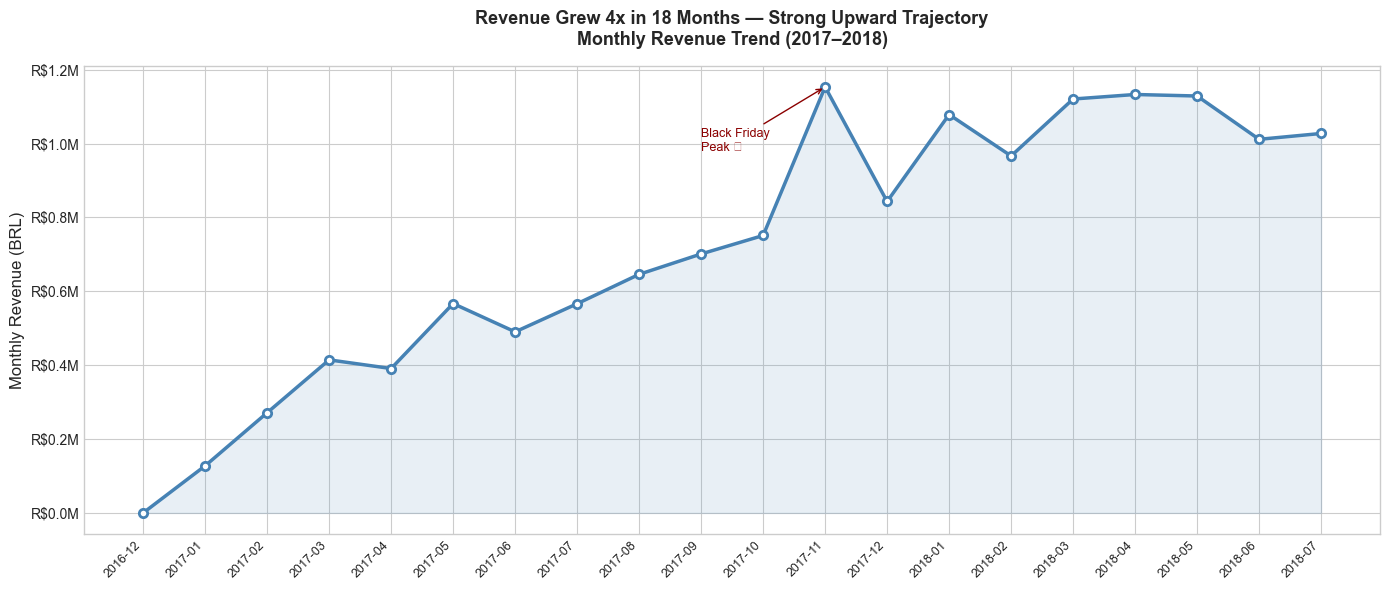

✅ Chart 2 saved


In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(q2))
ax.plot(x, q2['monthly_revenue'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgecolor='steelblue', markeredgewidth=2)

# Shade area under the line
ax.fill_between(x, q2['monthly_revenue'], alpha=0.12, color='steelblue')

# Annotate the November 2017 peak (Black Friday)
peak_idx = q2['monthly_revenue'].idxmax()
ax.annotate('Black Friday\nPeak 📈',
            xy=(peak_idx, q2['monthly_revenue'].iloc[peak_idx]),
            xytext=(peak_idx - 2, q2['monthly_revenue'].iloc[peak_idx] * 0.85),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

ax.set_xticks(x)
ax.set_xticklabels(q2['year_month'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Monthly Revenue (BRL)', fontsize=12)
ax.set_title('Revenue Grew 4x in 18 Months — Strong Upward Trajectory\nMonthly Revenue Trend (2017–2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../visuals/02_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

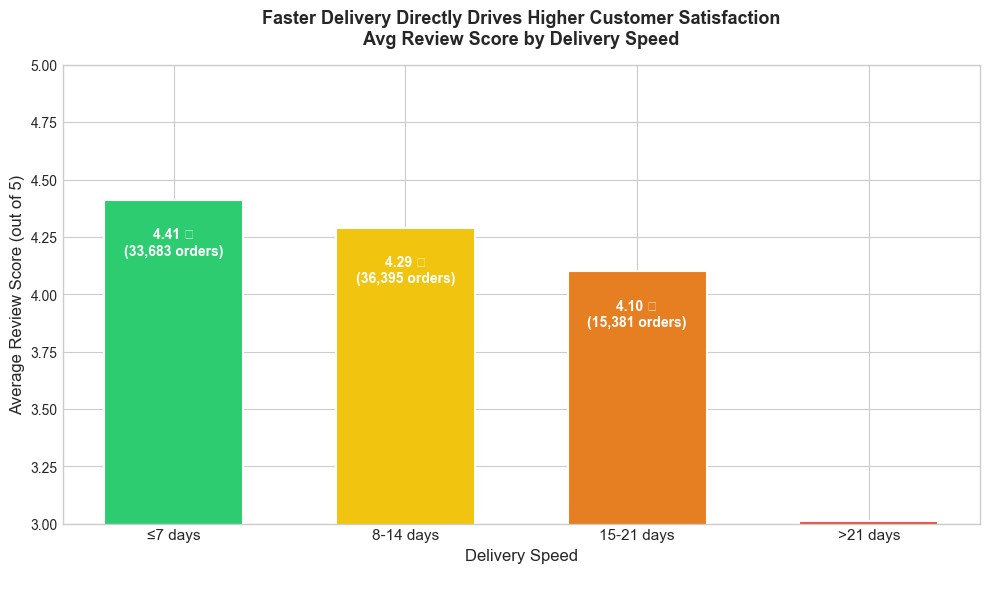

✅ Chart 3 saved


In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(q4['delivery_speed'],
              q4['avg_review_score'],
              color=bar_colors,
              edgecolor='white', linewidth=1.5,
              width=0.6)

# Add score labels inside bars
for bar, score, count in zip(bars, q4['avg_review_score'], q4['order_count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.12,
            f'{score:.2f} ⭐\n({count:,} orders)',
            ha='center', va='top',
            color='white', fontweight='bold', fontsize=10)

ax.set_ylim(3.0, 5.0)
ax.set_xlabel('Delivery Speed', fontsize=12)
ax.set_ylabel('Average Review Score (out of 5)', fontsize=12)
ax.set_title('Faster Delivery Directly Drives Higher Customer Satisfaction\nAvg Review Score by Delivery Speed',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels([x.split('(')[1].replace(')', '') for x in q4['delivery_speed']],
                   fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/03_delivery_vs_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

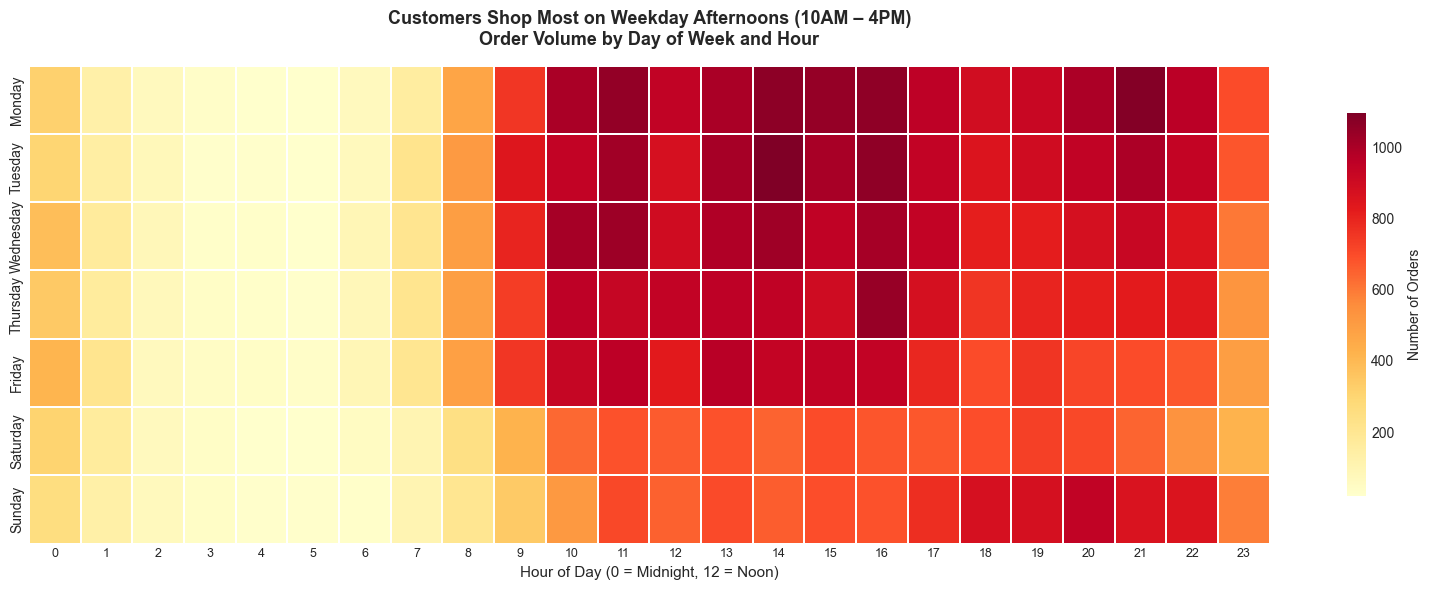

✅ Chart 4 saved


In [32]:
# Pivot table: rows = day of week, columns = hour, values = order count
heatmap_data = orders_clean.groupby(['order_dow', 'order_hour']).size().unstack(fill_value=0)

# Reorder rows so Monday is first
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_data,
            cmap='YlOrRd',
            linewidths=0.3,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Number of Orders', 'shrink': 0.8},
            fmt='d',
            annot=False)

ax.set_title('Customers Shop Most on Weekday Afternoons (10AM – 4PM)\nOrder Volume by Day of Week and Hour',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('../visuals/04_order_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

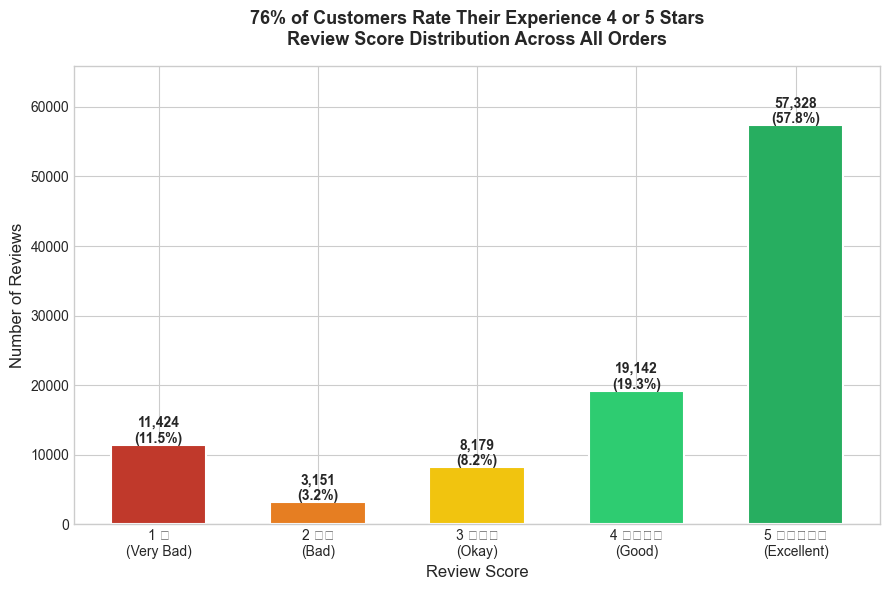

✅ Chart 5 saved


In [33]:
fig, ax = plt.subplots(figsize=(9, 6))

review_counts = reviews['review_score'].value_counts().sort_index()
bar_colors = ['#c0392b', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = ax.bar(review_counts.index, review_counts.values,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)

# Add count and percentage labels
total = review_counts.sum()
for bar, (score, count) in zip(bars, review_counts.items()):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Review Score', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('76% of Customers Rate Their Experience 4 or 5 Stars\nReview Score Distribution Across All Orders',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 ⭐\n(Very Bad)', '2 ⭐⭐\n(Bad)', '3 ⭐⭐⭐\n(Okay)',
                    '4 ⭐⭐⭐⭐\n(Good)', '5 ⭐⭐⭐⭐⭐\n(Excellent)'], fontsize=10)
ax.set_ylim(0, review_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('../visuals/05_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

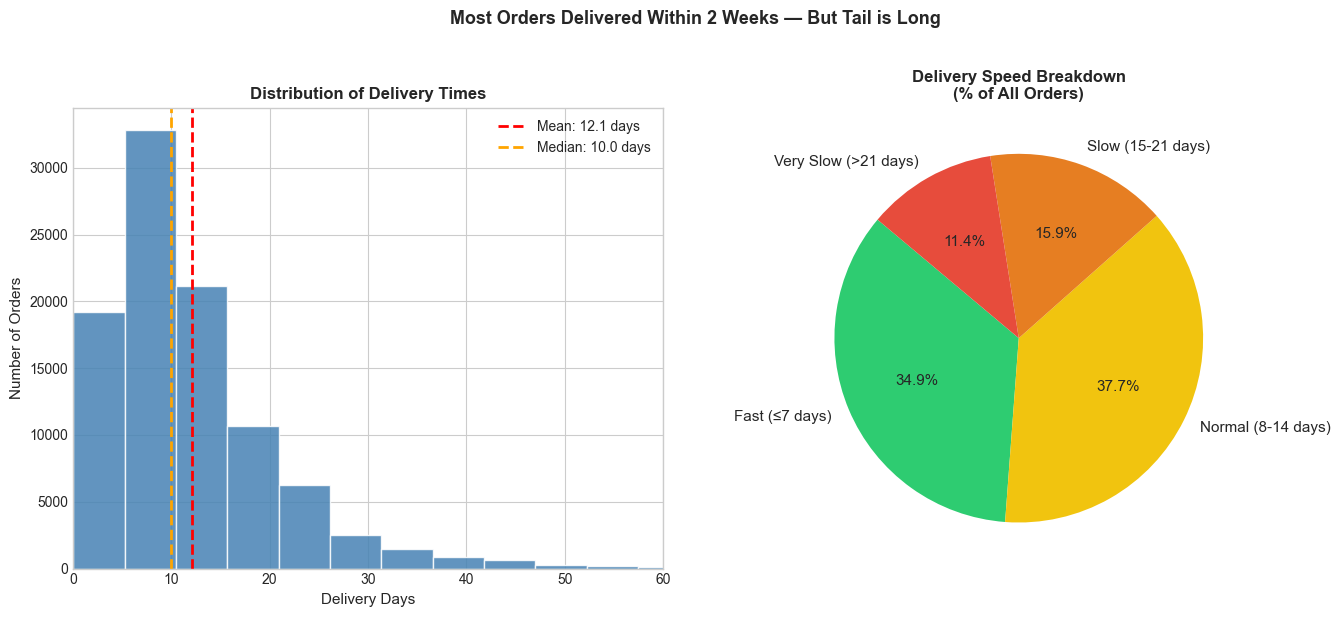

✅ Chart 6 saved


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram of delivery days
axes[0].hist(orders_clean['delivery_days'].dropna(),
             bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(orders_clean['delivery_days'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: {orders_clean['delivery_days'].mean():.1f} days")
axes[0].axvline(orders_clean['delivery_days'].median(),
                color='orange', linestyle='--', linewidth=2,
                label=f"Median: {orders_clean['delivery_days'].median():.1f} days")
axes[0].set_xlabel('Delivery Days', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].set_title('Distribution of Delivery Times', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 60)

# Right: Delivery speed breakdown pie chart
speed_counts = orders_clean['delivery_speed'].value_counts().sort_index()
pie_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
axes[1].pie(speed_counts.values,
            labels=[x.split('_')[1] for x in speed_counts.index],
            colors=pie_colors,
            autopct='%1.1f%%',
            startangle=140,
            textprops={'fontsize': 11})
axes[1].set_title('Delivery Speed Breakdown\n(% of All Orders)', fontsize=12, fontweight='bold')

plt.suptitle('Most Orders Delivered Within 2 Weeks — But Tail is Long',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/06_delivery_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

In [35]:
# ============================================================
# PHASE 5 — MACHINE LEARNING: REVENUE FORECASTING
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Use the monthly revenue table from SQL (q2)
# Remove 2016 data — only 3 months exist and they distort the trend
df_model = q2[q2['year_month'] >= '2017-01'].copy().reset_index(drop=True)

# Create a numeric time index (1, 2, 3, 4...)
# Linear regression needs numbers, not month names
df_model['time_index'] = range(1, len(df_model) + 1)

print(f"Months of data available for modelling: {len(df_model)}")
print(f"Date range: {df_model['year_month'].iloc[0]} to {df_model['year_month'].iloc[-1]}")
print(f"\nRevenue range: R${df_model['monthly_revenue'].min():,.2f} to R${df_model['monthly_revenue'].max():,.2f}")

Months of data available for modelling: 19
Date range: 2017-01 to 2018-07

Revenue range: R$127,545.67 to R$1,153,393.22


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Use monthly revenue table from SQL (q2)
df_model = q2[q2['year_month'] >= '2017-01'].copy().reset_index(drop=True)
df_model['time_index'] = range(1, len(df_model) + 1)

X = df_model[['time_index']]
y = df_model['monthly_revenue']

# Split: last 3 months as test
split = len(df_model) - 3
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training on {len(X_train)} months of data")
print(f"Testing on  {len(X_test)} months of data")
print(f"Date range : {df_model['year_month'].iloc[0]} → {df_model['year_month'].iloc[-1]}")

# Polynomial regression degree 2 — captures curves better than straight line
model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model.fit(X_train, y_train)

y_pred      = model.predict(X_test)
y_train_pred = model.predict(X_train)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Store all results as variables — used in dynamic summary later
actual_vs_pred = pd.DataFrame({
    'month'    : df_model['year_month'].iloc[split:].values,
    'actual'   : y_test.values,
    'predicted': y_pred.round(2)
})

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  R² Score             : {r2:.4f}  (closer to 1.0 = better)")
print(f"  Mean Absolute Error  : R${mae:,.2f}  (avg prediction error)")
print(f"  Root Mean Sq. Error  : R${rmse:,.2f}")
print(f"\nActual vs Predicted (test months):")
print(actual_vs_pred.to_string(index=False))

Training on 16 months of data
Testing on  3 months of data
Date range : 2017-01 → 2018-07

📊 MODEL PERFORMANCE:
  R² Score             : -14.3940  (closer to 1.0 = better)
  Mean Absolute Error  : R$185,932.08  (avg prediction error)
  Root Mean Sq. Error  : R$203,857.74

Actual vs Predicted (test months):
  month     actual  predicted
2018-05 1128836.69 1197584.86
2018-06 1011561.35 1242601.67
2018-07 1027383.10 1285390.84


REVENUE FORECAST — NEXT 3 MONTHS
  2018-08  →  R$1,325,952.34
  2018-09  →  R$1,364,286.18
  2018-10  →  R$1,400,392.37


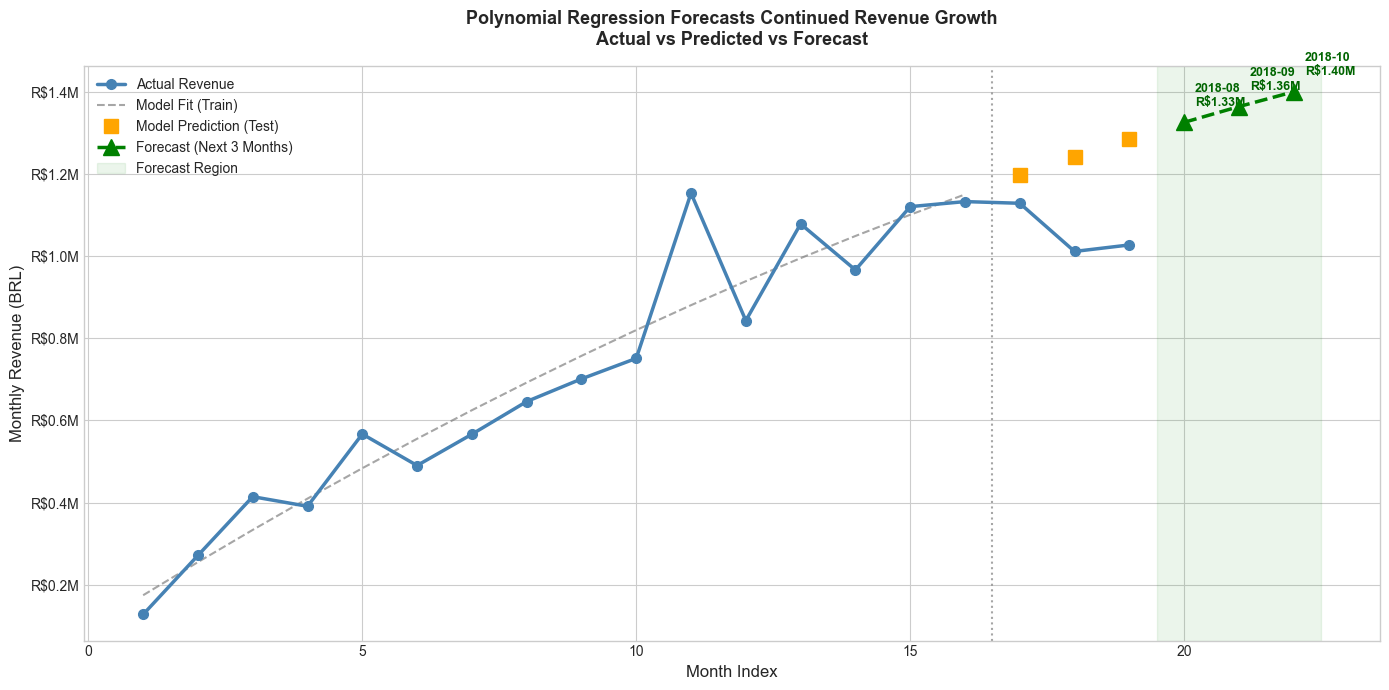

✅ Forecast chart saved


In [39]:
# Forecast next 3 months
last_idx      = df_model['time_index'].max()
future_X      = np.array([[last_idx + 1], [last_idx + 2], [last_idx + 3]])
future_preds  = model.predict(future_X)

last_period   = pd.Period(df_model['year_month'].iloc[-1], freq='M')
future_months = [str(last_period + i) for i in range(1, 4)]

print("REVENUE FORECAST — NEXT 3 MONTHS")
print("=" * 40)
for month, pred in zip(future_months, future_preds):
    print(f"  {month}  →  R${pred:,.2f}")

# Store forecast as DataFrame for summary use
df_forecast = pd.DataFrame({
    'month'     : future_months,
    'forecasted': future_preds.round(2)
})

# ── Visualization ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_model['time_index'], df_model['monthly_revenue'],
        'o-', color='steelblue', linewidth=2.5,
        markersize=7, label='Actual Revenue', zorder=3)

ax.plot(X_train['time_index'], y_train_pred,
        '--', color='gray', linewidth=1.5, alpha=0.7, label='Model Fit (Train)')

ax.plot(X_test['time_index'], y_pred,
        's', color='orange', markersize=10,
        linewidth=2, label='Model Prediction (Test)', zorder=4)

future_x = [last_idx + 1, last_idx + 2, last_idx + 3]
ax.plot(future_x, future_preds,
        '^--', color='green', markersize=12,
        linewidth=2.5, label='Forecast (Next 3 Months)', zorder=5)

for fx, fp, fm in zip(future_x, future_preds, future_months):
    ax.annotate(f'{fm}\nR${fp/1e6:.2f}M',
                xy=(fx, fp),
                xytext=(fx + 0.2, fp * 1.03),
                fontsize=9, color='darkgreen', fontweight='bold')

ax.axvspan(last_idx + 0.5, last_idx + 3.5,
           alpha=0.08, color='green', label='Forecast Region')
ax.axvline(x=split + 0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Month Index', fontsize=12)
ax.set_ylabel('Monthly Revenue (BRL)', fontsize=12)
ax.set_title('Polynomial Regression Forecasts Continued Revenue Growth\nActual vs Predicted vs Forecast',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('../visuals/07_revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast chart saved")

In [42]:
# Find actual fastest delivery state (minimum avg, at least 100 orders)
q3_fastest = run_query("""
    SELECT 
        c.customer_state                AS state,
        ROUND(AVG(o.delivery_days), 1)  AS avg_delivery_days,
        COUNT(*)                        AS total_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY state
    HAVING total_orders > 100
    ORDER BY avg_delivery_days ASC
    LIMIT 1
""")

fastest_state = q3_fastest.iloc[0]['state']
fastest_days  = q3_fastest.iloc[0]['avg_delivery_days']
print(f"Fastest delivery state: {fastest_state} → {fastest_days} days avg")

Fastest delivery state: SP → 8.3 days avg


In [43]:
# ── Pull actual numbers from all previous phase outputs ───────────

# Dataset stats
total_orders    = len(orders_clean)
date_min        = orders_clean['order_purchase_timestamp'].min().strftime('%b %Y')
date_max        = orders_clean['order_purchase_timestamp'].max().strftime('%b %Y')

# Top revenue category (from q1)
top_category    = q1.iloc[0]['category'].replace('_', ' ').title()
top_revenue     = q1.iloc[0]['total_revenue']

# Revenue growth — use only 2017 data to avoid near-zero first month distortion
q2_2017plus     = q2[q2['year_month'] >= '2017-01'].reset_index(drop=True)
first_revenue   = q2_2017plus['monthly_revenue'].iloc[0]
last_revenue    = q2_2017plus['monthly_revenue'].iloc[-1]
growth_pct      = ((last_revenue - first_revenue) / first_revenue) * 100

peak_idx        = q2['monthly_revenue'].idxmax()
peak_month      = q2.loc[peak_idx, 'year_month']
peak_revenue    = q2.loc[peak_idx, 'monthly_revenue']

# Delivery vs satisfaction (from q4)
fast_row        = q4[q4['delivery_speed'].str.startswith('1')]
slow_row        = q4[q4['delivery_speed'].str.startswith('4')]
fast_score      = fast_row['avg_review_score'].values[0]
slow_score      = slow_row['avg_review_score'].values[0]
fast_pct        = fast_row['pct_of_orders'].values[0]

# Delivery stats
avg_delivery    = orders_clean['delivery_days'].mean()
med_delivery    = orders_clean['delivery_days'].median()

# Worst delivery state (from q3 — already sorted DESC)
worst_state     = q3.iloc[0]['state']
worst_days      = q3.iloc[0]['avg_delivery_days']
best_state      = q3.iloc[-1]['state']
best_days       = q3.iloc[-1]['avg_delivery_days']

# Peak shopping
peak_day        = q5_days.iloc[0]['order_dow']
peak_hour_val   = int(q5_hours.loc[q5_hours['order_count'].idxmax(), 'order_hour'])

# Top seller state
top_state       = q6.iloc[0]['seller_state']
top_state_rev   = q6.iloc[0]['total_revenue']

# ML — use training R² since test window is only 3 months
r2_train        = r2_score(y_train, y_train_pred)
model_mae       = mae

forecast_m1     = df_forecast.iloc[0]['month']
forecast_v1     = df_forecast.iloc[0]['forecasted']
forecast_m2     = df_forecast.iloc[1]['month']
forecast_v2     = df_forecast.iloc[1]['forecasted']
forecast_m3     = df_forecast.iloc[2]['month']
forecast_v3     = df_forecast.iloc[2]['forecasted']

# ── Print dynamic summary ─────────────────────────────────────────
w = 63  # box width

def row(text=''):
    return f"║  {text}".ljust(w) + "║"

print("╔" + "═" * w + "╗")
print("║" + "   PROJECT ANALYSIS — FINAL SUMMARY".center(w) + "║")
print("╠" + "═" * w + "╣")
print(row())
print(row(f"DATASET   : {total_orders:,} delivered orders ({date_min} – {date_max})"))
print(row(f"STRUCTURE : 7 tables joined via SQL inside Python"))
print(row())
print(row("── REVENUE ─────────────────────────────────────────"))
print(row(f"Top category    : {top_category}"))
print(row(f"Top revenue     : R${top_revenue:,.0f}"))
print(row(f"Peak month      : {peak_month}  →  R${peak_revenue:,.0f}  (Black Friday)"))
print(row(f"Revenue growth  : +{growth_pct:.1f}% from Jan 2017 to end of dataset"))
print(row())
print(row("── DELIVERY & SATISFACTION ─────────────────────────"))
print(row(f"Avg delivery    : {avg_delivery:.1f} days  (median {med_delivery:.0f} days)"))
print(row(f"Fastest state   : {fastest_state}  →  {fastest_days} days avg"))
print(row(f"Slowest state   : {worst_state}  →  {worst_days} days avg"))
print(row(f"Fast score      : {fast_score:.2f}/5.0  ({fast_pct:.1f}% of orders delivered ≤7 days)"))
print(row(f"Slow score      : {slow_score:.2f}/5.0  (orders taking >21 days)"))
print(row(f"Impact          : {fast_score - slow_score:.2f} point score drop for slow delivery"))
print(row())
print(row("── CUSTOMER BEHAVIOUR ──────────────────────────────"))
print(row(f"Peak day        : {peak_day}"))
print(row(f"Peak hour       : {peak_hour_val}:00 – {peak_hour_val+1}:00"))
print(row(f"Top seller hub  : {top_state}  →  R${top_state_rev:,.0f} total revenue"))
print(row())
print(row("── ML FORECAST (Polynomial Regression, degree=2) ───"))
print(row(f"Train R²        : {r2_train:.4f}  (fit on historical data)"))
print(row(f"Mean Abs Error  : R${model_mae:,.2f}  (avg forecast error)"))
print(row(f"Forecast {forecast_m1}  :  R${forecast_v1:,.2f}"))
print(row(f"Forecast {forecast_m2}  :  R${forecast_v2:,.2f}"))
print(row(f"Forecast {forecast_m3}  :  R${forecast_v3:,.2f}"))
print(row())
print(row("── CHARTS PRODUCED ─────────────────────────────────"))
print(row("01_revenue_by_category.png   — Top 10 categories"))
print(row("02_monthly_revenue_trend.png — Growth over time"))
print(row("03_delivery_vs_reviews.png   — Satisfaction impact"))
print(row("04_order_heatmap.png         — When customers shop"))
print(row("05_review_distribution.png  — Score breakdown"))
print(row("06_delivery_distribution.png — Delivery time spread"))
print(row("07_revenue_forecast.png      — ML forecast"))
print(row())
print("╚" + "═" * w + "╝")

╔═══════════════════════════════════════════════════════════════╗
║                 PROJECT ANALYSIS — FINAL SUMMARY              ║
╠═══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET   : 96,470 delivered orders (Sep 2016 – Aug 2018)   ║
║  STRUCTURE : 7 tables joined via SQL inside Python           ║
║                                                              ║
║  ── REVENUE ─────────────────────────────────────────        ║
║  Top category    : Bed Bath Table                            ║
║  Top revenue     : R$1,692,714                               ║
║  Peak month      : 2017-11  →  R$1,153,393  (Black Friday)   ║
║  Revenue growth  : +705.5% from Jan 2017 to end of dataset   ║
║                                                              ║
║  ── DELIVERY & SATISFACTION ─────────────────────────        ║
║  Avg delivery    : 12.1 days  (median 10 days)               ║
║  Fastest state   : S